In [2]:
import os, sys, pickle
import numpy as np
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn as nn
from torchinfo import summary
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
import albumentations as A
from pathlib import Path
import wandb
from tqdm import tqdm
sns.set()
api = wandb.Api()

sys.path.append(os.path.abspath("."))
from src_vae.train import train_vae
from src_vae.model import VAEModel
from src_vae.data import ZiramF0Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

import datetime

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score, accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

Using device: cpu


In [3]:
X_train = ZiramF0Dataset(img_type="full_dataset", train=True, val=False, test=False, apply_transform=False)
X_val = ZiramF0Dataset(img_type="full_dataset", train=False, val=True, test=False, apply_transform=False)

# Load all image
loader_train = DataLoader(X_train, batch_size=X_train.__len__(), shuffle=False, num_workers=1, pin_memory=True)
train_all = next(iter(loader_train))
loader_val = DataLoader(X_val, batch_size=X_val.__len__(), shuffle=False, num_workers=1, pin_memory=True)
val_all = next(iter(loader_val))

### Getting mapping between sweep run names & their hyperparameters from wandb

In [2]:
sweep_id = "mmosfr4n"
sweep_dir = f"/nfs/research/birney/users/esther/medaka-ziram/results/sweep_{sweep_id}"

run_dirs = [p.name for p in Path(sweep_dir).iterdir() if p.is_dir()]

api = wandb.Api() # Initialize wandb api

sweep = api.sweep(f"ey267-university-of-cambridge/Ziram VAE Training/{sweep_id}")

In [3]:
# Sometimes skips over a bunch of runs; check length of values and restart kernel if this is the case
name_to_hyperpararms = {
    "run_name": [],
    "run_id": [],
    "latent_dim": [],
    # "capacity": [],
    # "depth": [],
    "kld_b": [],
    "batch_size": [],
    # "dropout_p": [],
    "val_recon_loss": []
}
for run in sweep.runs:
    run_log = api.run(f"ey267-university-of-cambridge/Ziram VAE Training/{sweep_id}/{run.id}")
    # print(run.name)
    name_to_hyperpararms["run_name"].append(run.name)
    name_to_hyperpararms["run_id"].append(run.id)
    name_to_hyperpararms["latent_dim"].append(run_log.config['latent_dim'])
    # name_to_hyperpararms["capacity"].append(run_log.config['capacity'])
    # name_to_hyperpararms["depth"].append(run_log.config['depth'])
    name_to_hyperpararms["kld_b"].append(run_log.config['kld_b'])
    name_to_hyperpararms["batch_size"].append(run_log.config['batch_size'])
    # name_to_hyperpararms["dropout_p"].append(run_log.config['dropout_p'])
    name_to_hyperpararms["val_recon_loss"].append(run_log.summary['epoch_test_recon_loss'])

print(len(name_to_hyperpararms['run_name']))

200


In [8]:
name_to_hyperpararms

{'run_name': ['olive-sweep-1',
  'swept-sweep-2',
  'floral-sweep-3',
  'amber-sweep-4',
  'helpful-sweep-6',
  'sweet-sweep-5',
  'twilight-sweep-8',
  'autumn-sweep-7',
  'graceful-sweep-9',
  'toasty-sweep-10',
  'tough-sweep-11',
  'laced-sweep-12',
  'bright-sweep-13',
  'still-sweep-14',
  'flowing-sweep-15',
  'dainty-sweep-16',
  'gallant-sweep-17',
  'youthful-sweep-18',
  'peach-sweep-19',
  'royal-sweep-20',
  'legendary-sweep-21',
  'firm-sweep-22',
  'amber-sweep-23',
  'devoted-sweep-24',
  'charmed-sweep-25',
  'balmy-sweep-26',
  'sage-sweep-27',
  'cerulean-sweep-28',
  'dry-sweep-29',
  'deft-sweep-30',
  'kind-sweep-31',
  'rural-sweep-32',
  'sleek-sweep-33',
  'crimson-sweep-34',
  'zany-sweep-35',
  'eager-sweep-36',
  'absurd-sweep-37',
  'clean-sweep-38',
  'still-sweep-39',
  'wise-sweep-40',
  'stellar-sweep-41',
  'glamorous-sweep-42',
  'cerulean-sweep-43',
  'sage-sweep-44',
  'exalted-sweep-45',
  'major-sweep-46',
  'distinctive-sweep-47',
  'copper-sweep

In [4]:
import csv

with open(f"/nfs/research/birney/users/esther/medaka-ziram/results/sweep_{sweep_id}/runs_name_to_id_hyperparams.csv", "w", newline="") as f:
    writer = csv.writer(f)

    # Write column headers
    writer.writerow(name_to_hyperpararms.keys())

    # Write rows
    writer.writerows(zip(*name_to_hyperpararms.values()))

In [22]:
len(run_dirs)

97

### Load pretrained

In [ ]:
# model_dir = "/nfs/research/birney/users/esther/medaka-ziram/results/sweep_0a39n1bn/20260629-1523_lunar-sweep-29/" # Best classification model
# model_dir = "/nfs/research/birney/users/esther/medaka-ziram/results/sweep_0a39n1bn/20260629-1832_robust-sweep-63/"

# Get parameters via wandb
sweep_id = "6o8li1mg"

# For sweep = 0a39n1bn (non-resnet, F0 only training)
# 20260629-1523_lunar-sweep-29 # best classifying
# 20260629-1832_robust-sweep-63 # best reconstructing

# For sweep = mmosfr4n (resnet, F0 only training)
# 20260705-0442_magic-sweep-70 # best classifying
# 20260705-2039_glowing-sweep-110 # best reconstructing

# For sweep = 6o8li1mg (resnet, F0 + F2 training)


model_dir = f"/nfs/research/birney/users/esther/medaka-ziram/results/sweep_{sweep_id}/20260708-0348_valiant-sweep-33/"

# runs_map_df = pd.read_csv(f"/nfs/research/birney/users/esther/medaka-ziram/results/sweep_{sweep_id}/runs_name_to_id_hyperparams.csv")
# runs_map_dict = dict(zip(runs_map_df["run_name"], runs_map_df["run_id"]))

# run_name = os.path.basename(model_dir[:-1]).split("_", 1)[1]
# run_id = runs_map_dict[run_name]
run_id = "2d45nh0d"
run = api.run(f"ey267-university-of-cambridge/Ziram VAE Training/{sweep_id}/{run_id}")

# model = VAEModel(
#     input_dim=X_train[0][0].shape,
#     latent_dim=run.config['latent_dim'],
#     kld_b=run.config['kld_b'],
#     batch_size=run.config['batch_size'],

#     capacity=run.config['capacity'],
#     depth=run.config['depth'],
#     dropout_p=run.config['dropout_p'],
#     device=device
# )

model = VAEModel(
    input_dim=X_train[0][0].shape,
    latent_dim=256,
    kld_b=0.0001,
    batch_size=16,
)

model_ckpt = torch.load(model_dir + "model.pt", map_location=torch.device('cpu')) # Change this back when I have GPUs again
model.load_state_dict(model_ckpt,
                      strict=False)
model.eval()

input_dim:  torch.Size([1, 352, 352])
latent_dim:  256
capacity:  64
depth:  4
batch_size:  16
dropout:  0.0
Model is ResNet


/tmp/ipykernel_2304133/1943053984.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ckpt = torch.load(model_dir + "model.pt", map_location=torch.device('cpu'))


VAEModel(
  (vae): VAE_ResNet(
    (encoder): ResNet(
      (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm

In [20]:
summary(model.vae.encoder, input_size=(10, 1, 352, 352))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [10, 512]                 --
├─Conv2d: 1-1                            [10, 64, 176, 176]        3,136
├─BatchNorm2d: 1-2                       [10, 64, 176, 176]        128
├─ReLU: 1-3                              [10, 64, 176, 176]        --
├─MaxPool2d: 1-4                         [10, 64, 88, 88]          --
├─Sequential: 1-5                        [10, 64, 88, 88]          --
│    └─BasicBlock: 2-1                   [10, 64, 88, 88]          --
│    │    └─Conv2d: 3-1                  [10, 64, 88, 88]          36,864
│    │    └─BatchNorm2d: 3-2             [10, 64, 88, 88]          128
│    │    └─ReLU: 3-3                    [10, 64, 88, 88]          --
│    │    └─Conv2d: 3-4                  [10, 64, 88, 88]          36,864
│    │    └─BatchNorm2d: 3-5             [10, 64, 88, 88]          128
│    │    └─ReLU: 3-6                    [10, 64, 88, 88]          --
│

### View validation reconstruction

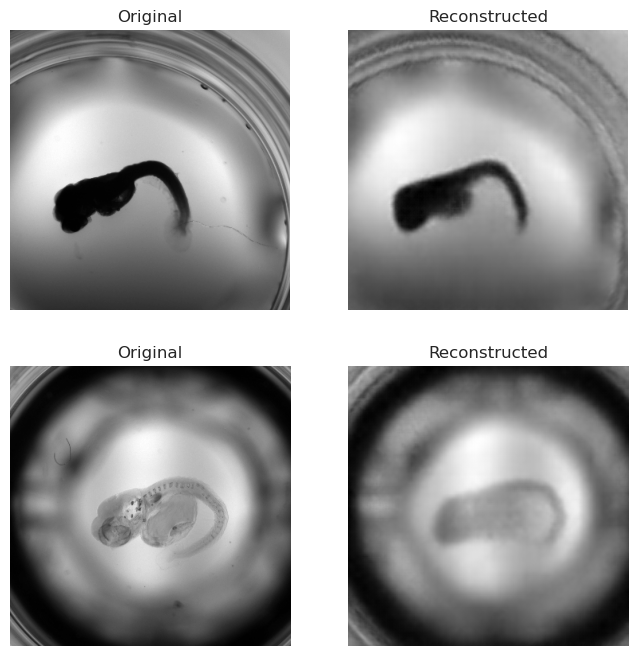

In [8]:
idx = 0 # Sample index to reconstruct

sample = X_val[idx]
recon = model.vae(sample[0].unsqueeze(0).to(device))

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs[0, 0].imshow(sample[0].squeeze(0).cpu().detach(), cmap='gray')
axs[0, 0].set_title('Original')
axs[0, 0].axis('off')
axs[0, 1].imshow(recon[0].squeeze(0).squeeze(0).cpu().detach(), cmap='gray')
axs[0, 1].set_title('Reconstructed')
axs[0, 1].axis('off')

idx = 60 # Sample index to reconstruct
sample = X_val[idx]
recon = model.vae(sample[0].unsqueeze(0).to(device))

axs[1, 0].imshow(sample[0].squeeze(0).cpu().detach(), cmap='gray')
axs[1, 0].set_title('Original')
axs[1, 0].axis('off')
axs[1, 1].imshow(recon[0].squeeze(0).squeeze(0).cpu().detach(), cmap='gray')
axs[1, 1].set_title('Reconstructed')
axs[1, 1].axis('off')
plt.savefig(f"{model_dir}/validation_reconstruction.png", dpi=300, bbox_inches='tight')
plt.show()

### Get VAE latents

In [7]:
# Get latent mean, logvar for each sample
train_all_means, train_all_logvars = model.vae.get_latent(
    train_all[0].to(device)
)
val_all_means, val_all_logvars = model.vae.get_latent(
    val_all[0].to(device)
)
train_all_means = train_all_means.detach().cpu().numpy()
train_all_logvars = train_all_logvars.detach().cpu().numpy()
val_all_means = val_all_means.detach().cpu().numpy()
val_all_logvars = val_all_logvars.detach().cpu().numpy()

In [12]:
# Save latents as pkl (to send to Fanny)
import pickle

### Train latents
data = []

for batch in loader_train:
    imgs, labels, arr, img_paths, empty, metadata = batch
    
    with torch.no_grad():
        mu, log_var = model.vae.get_latent(imgs.to(device))
    
    data.append({
        'img_paths': img_paths,
        'mu': mu.cpu().numpy(),
        'log_var': log_var.cpu().numpy(),
        'generation': metadata['generation'],
        'severity_score': metadata['severity_score'],
        'severity_score_adjusted': metadata['severity_score_adjusted'],
        'plate': metadata['plate'],
        'well': metadata['well'],
        'line': metadata['line'],
        'exposure_type': metadata['exposure_type'],
        'cross': metadata['cross'],
        'tank': metadata['tank']
    })

print(len(data[0]['img_paths']))

with open(f'{model_dir}/latents_train.pkl', 'wb') as f:
    pickle.dump(data, f)


### Validation latents
data = []

for batch in loader_val:
    imgs, labels, arr, img_paths, empty, metadata = batch
    
    with torch.no_grad():
        mu, log_var = model.vae.get_latent(imgs.to(device))
    
    data.append({
        'img_paths': img_paths,
        'mu': mu.cpu().numpy(),
        'log_var': log_var.cpu().numpy(),
        'generation': metadata['generation'],
        'severity_score': metadata['severity_score'],
        'severity_score_adjusted': metadata['severity_score_adjusted'],
        'plate': metadata['plate'],
        'well': metadata['well'],
        'line': metadata['line'],
        'exposure_type': metadata['exposure_type'],
        'cross': metadata['cross'],
        'tank': metadata['tank']
    })

print(len(data[0]['img_paths']))

with open(f'{model_dir}/latents_val.pkl', 'wb') as f:
    pickle.dump(data, f)

577
408


### Validation on held-out set

In [11]:
def make_clfs():
    """Fresh classifier instances (avoid any shared state between calls/tasks)."""
    return [('LogReg', LogisticRegression(max_iter=3000)),
            ('RF', RandomForestClassifier(n_estimators=300, random_state=0))]


def res_row(name, task, nm, protocol, y_true, y_pred, dims, n_train, n_eval):
    binary = (task == 'binary')
    r = dict(method=name, task=task, classifier=nm, protocol=protocol,
             n_train=n_train, n_eval=n_eval, dims=dims,
             acc=accuracy_score(y_true, y_pred),
             macroF1=f1_score(y_true, y_pred, average='macro'),
             weightedF1=f1_score(y_true, y_pred, average='weighted'),
             quadKappa=cohen_kappa_score(y_true, y_pred, weights=None if binary else 'quadratic'))
    return r


def output_print(nm, r, binary, y_true=None, y_pred=None):
    if binary:
        extra = f"F1(affected)={f1_score(y_true, y_pred):.3f} " if y_true is not None else ""
        print(f"    {nm:7s} acc={r['acc']:.3f} {extra}macroF1={r['macroF1']:.3f} kappa={r['quadKappa']:.3f}")
    else:
        print(f"    {nm:7s} acc={r['acc']:.3f} macroF1={r['macroF1']:.3f} "
              f"weightedF1={r['weightedF1']:.3f} quadKappa={r['quadKappa']:.3f}")

def report_holdout(Xtr, ytr, Xte, yte, name):
    """RECOMMENDED: fit on TRAIN, evaluate on HELD-OUT. Scaler fit on TRAIN only (no leakage)."""
    sc = StandardScaler().fit(np.asarray(Xtr, dtype=float))          # <-- fit on TRAIN ONLY
    Xtr = sc.transform(np.asarray(Xtr, dtype=float))
    Xte = sc.transform(np.asarray(Xte, dtype=float))
    ytr = np.asarray(ytr).astype(int); yte = np.asarray(yte).astype(int)
    ntr, nte, dims = len(ytr), len(yte), Xtr.shape[1]
    rows, cms = [], {}
    print(f"\n=== {name}  [HOLD-OUT]  (train n={ntr}, eval n={nte}, dims={dims}, "
          f"train classes={np.bincount(ytr).tolist()}, eval classes={np.bincount(yte).tolist()}) ===")
    print("  5-class (severity SC0-4):")
    for nm, clf in make_clfs():
        clf.fit(Xtr, ytr); yp = clf.predict(Xte)
        r = res_row(name, '5class', nm, 'holdout', yte, yp, dims, ntr, nte)
        rows.append(r); cms[f'5class_{nm}'] = confusion_matrix(yte, yp)
        output_print(nm, r, binary=False)
    ytr_b, yte_b = (ytr > 0).astype(int), (yte > 0).astype(int)
    print("  binary (SC0 vs any-kink):")
    for nm, clf in make_clfs():
        clf.fit(Xtr, ytr_b); yp = clf.predict(Xte)
        r = res_row(name, 'binary', nm, 'holdout', yte_b, yp, dims, ntr, nte)
        rows.append(r); cms[f'binary_{nm}'] = confusion_matrix(yte_b, yp)
        output_print(nm, r, binary=True, y_true=yte_b, y_pred=yp)
    return rows, cms

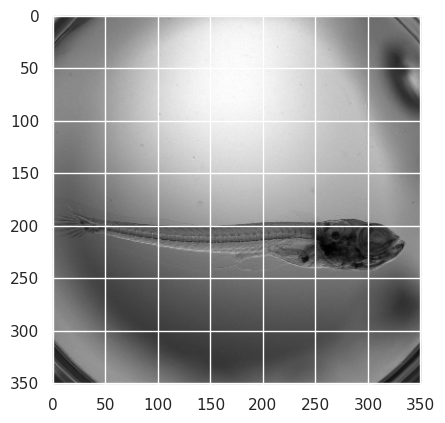

In [26]:
plt.imshow(train_all[0][1].squeeze(0).cpu().detach(), cmap="gray")

In [12]:
val_f0_idx = [i for i, value in enumerate(val_all[5]['generation']) if value == "F0"]
val_f2_idx = [i for i, value in enumerate(val_all[5]['generation']) if value == "F2"]

print(set(val_f0_idx) & set(val_f2_idx))

set()



=== 20260708-0348_valiant-sweep-33  [HOLD-OUT]  (train n=1114, eval n=204, dims=256, train classes=[217, 380, 224, 158, 135], eval classes=[42, 104, 38, 14, 6]) ===
  5-class (severity SC0-4):
    LogReg  acc=0.480 macroF1=0.257 weightedF1=0.454 quadKappa=0.148
    RF      acc=0.490 macroF1=0.170 weightedF1=0.373 quadKappa=0.021
  binary (SC0 vs any-kink):
    LogReg  acc=0.755 F1(affected)=0.849 macroF1=0.596 kappa=0.194
    RF      acc=0.804 F1(affected)=0.890 macroF1=0.491 kappa=0.074

[OK] saved metrics_20260708-0348_valiant-sweep-33.csv (+ confusion matrices) -> /nfs/research/birney/users/esther/medaka-ziram/results/sweep_6o8li1mg/20260708-0348_valiant-sweep-33//
[OK] master comparison table -> /nfs/research/birney/users/esther/medaka-ziram/results/sweep_6o8li1mg/20260708-0348_valiant-sweep-33/all_methods_comparison.csv


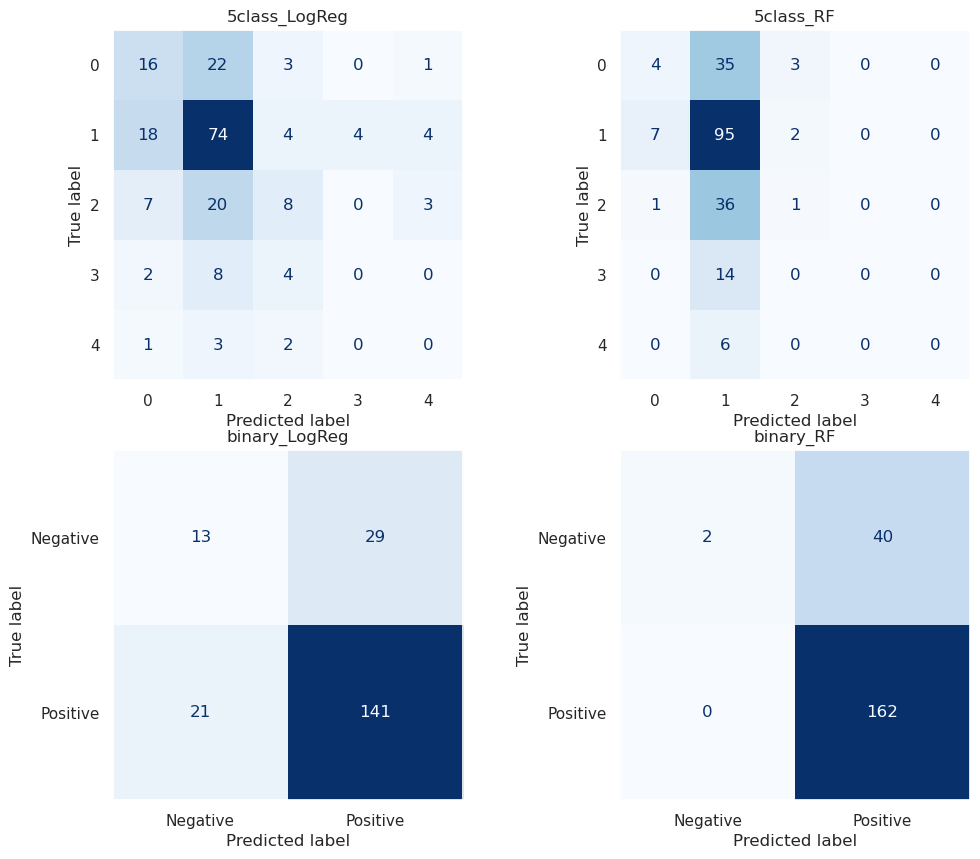

In [17]:
# Run standard evaluation for VAE results
std_eval_name = os.path.basename(model_dir[:-1])

rows, cms = report_holdout(Xtr = train_all_means,
                           ytr = train_all[5]['severity_score_adjusted'].detach().cpu().numpy(),
                           Xte = val_all_means[val_f2_idx],
                           yte = val_all[5]['severity_score_adjusted'].detach().cpu().numpy()[val_f2_idx],
                           name = std_eval_name)

# Show output
output_dir = model_dir
safe = ''.join(c if c.isalnum() or c in '-_' else '_' for c in std_eval_name)
run_df = pd.DataFrame(rows)
run_df.to_csv(os.path.join(output_dir, f'metrics_{safe}.csv'), index=False)
for k, cm in cms.items():
    np.savetxt(os.path.join(output_dir, f'confusion_{safe}_{k}.csv'), cm, fmt='%d', delimiter=',')
master = os.path.join(output_dir, 'all_methods_comparison.csv')
prev = pd.read_csv(master) if os.path.exists(master) else pd.DataFrame()
if len(prev):   # re-running a name overwrites its old rows
    key = ['method', 'task', 'classifier']
    prev = prev[~prev[key].apply(tuple, 1).isin(run_df[key].apply(tuple, 1))]
pd.concat([prev, run_df], ignore_index=True).to_csv(master, index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

### Save confusion matrix
for ax, (name, cm) in zip(axes, cms.items()):
    # Choose labels based on matrix size
    if cm.shape[0] == 2:
        labels = ["Negative", "Positive"]
    else:
        labels = [str(i) for i in range(cm.shape[0])]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.grid(False)

# fig.suptitle(f"Confusion matrices for run {std_eval_name}")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/cm.png", dpi=300, bbox_inches='tight')

print(f"\n[OK] saved metrics_{safe}.csv (+ confusion matrices) -> {output_dir}/")
print(f"[OK] master comparison table -> {master}")

### Standard eval (held-out) on CNN results

In [76]:
# cnn_filename = "cnn_reg_augm_bal_5_1_features"
cnn_filename = "cnn_reg_6_valf2_features"

cnn_features_train = pd.read_csv(f"/nfs/research/birney/users/esther/medaka-ziram/genetics_results/{cnn_filename}_training.csv")
cnn_features_val = pd.read_csv(f"/nfs/research/birney/users/esther/medaka-ziram/genetics_results/{cnn_filename}_validation.csv")
f2_img_names = pd.read_csv("/nfs/research/birney/users/esther/medaka-ziram/genetics_results/Gronske_IID_imgpth_full_F2_merged.csv")

In [77]:
cnn_features_val["fish_id2"] = cnn_features_val["fish_id"].str.replace(r"^W[^-]*--", "", regex=True)
f2_img_names["fish_id2"] = f2_img_names["image_path"].apply(
    lambda p: os.path.splitext(os.path.basename(p))[0] if pd.notna(p) else None
)

cnn_features_val_onlyf2 = cnn_features_val.merge(f2_img_names, on="fish_id2", how="inner").drop(columns = ["fish_id", "fish_id2", "image_path", "#IID", "merged"])
# cnn_features_val_onlyf0 = 

/tmp/ipykernel_509862/2239836847.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cnn_features_val["fish_id2"] = cnn_features_val["fish_id"].str.replace(r"^W[^-]*--", "", regex=True)


(204, 512)

=== cnn_reg_6_valf2_features  [HOLD-OUT]  (train n=743, eval n=204, dims=512, train classes=[139, 139, 160, 157, 148], eval classes=[42, 104, 38, 14, 6]) ===
  5-class (severity SC0-4):
    LogReg  acc=0.270 macroF1=0.216 weightedF1=0.297 quadKappa=0.320
    RF      acc=0.368 macroF1=0.260 weightedF1=0.371 quadKappa=0.363
  binary (SC0 vs any-kink):
    LogReg  acc=0.740 F1(affected)=0.828 macroF1=0.647 kappa=0.298
    RF      acc=0.789 F1(affected)=0.865 macroF1=0.691 kappa=0.383


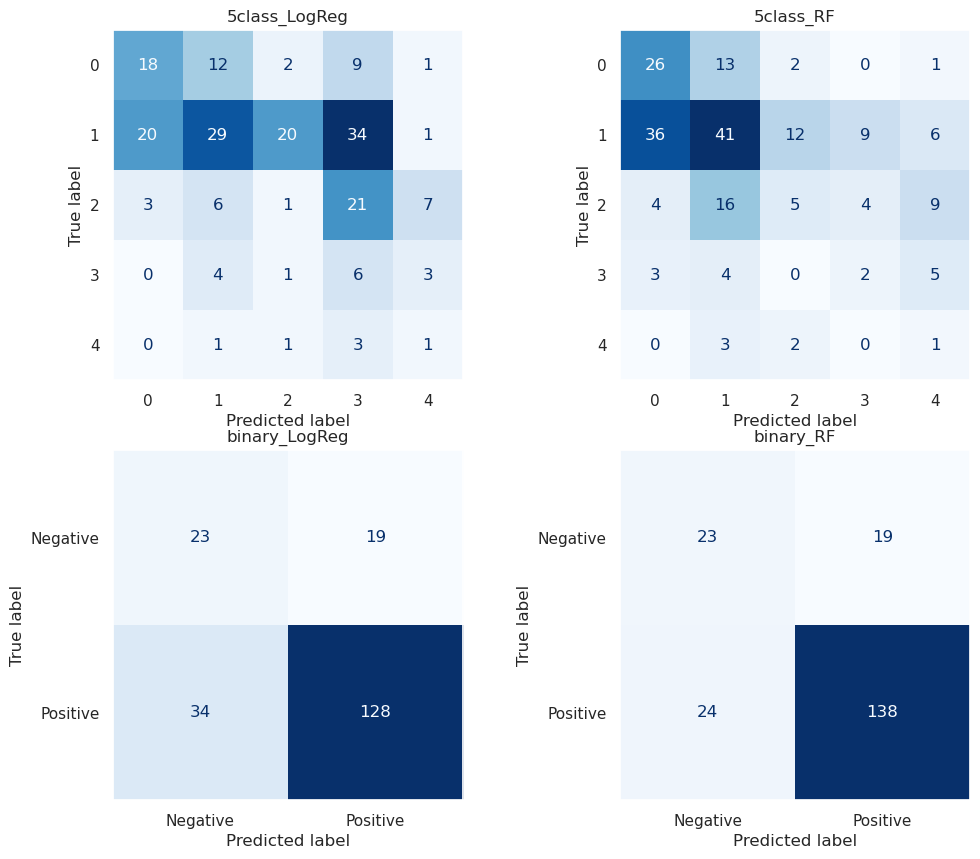

In [78]:
# Run standard evaluation for CNN results
Xtr = cnn_features_train.drop(columns = ["fish_id", "label"]).to_numpy()
ytr = cnn_features_train['label'].to_numpy()
Xte = cnn_features_val_onlyf2.drop(columns = ["label"]).to_numpy()
yte = cnn_features_val_onlyf2['label'].to_numpy()

print(Xte.shape)

std_eval_name = cnn_filename

rows, cms = report_holdout(Xtr = Xtr,
                           ytr = ytr,
                           Xte = Xte,
                           yte = yte,
                           name = std_eval_name)

# Show output
# safe = ''.join(c if c.isalnum() or c in '-_' else '_' for c in std_eval_name)
# run_df = pd.DataFrame(rows)
# run_df.to_csv(os.path.join(output_dir, f'metrics_{safe}.csv'), index=False)
# for k, cm in cms.items():
#     np.savetxt(os.path.join(output_dir, f'confusion_{safe}_{k}.csv'), cm, fmt='%d', delimiter=',')
# master = os.path.join(output_dir, 'all_methods_comparison.csv')
# prev = pd.read_csv(master) if os.path.exists(master) else pd.DataFrame()
# if len(prev):   # re-running a name overwrites its old rows
#     key = ['method', 'task', 'classifier']
#     prev = prev[~prev[key].apply(tuple, 1).isin(run_df[key].apply(tuple, 1))]
# pd.concat([prev, run_df], ignore_index=True).to_csv(master, index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

### Save confusion matrix
for ax, (name, cm) in zip(axes, cms.items()):
    # Choose labels based on matrix size
    if cm.shape[0] == 2:
        labels = ["Negative", "Positive"]
    else:
        labels = [str(i) for i in range(cm.shape[0])]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.grid(False)

# fig.suptitle(f"Confusion matrices for run {std_eval_name}")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/cm.png", dpi=300, bbox_inches='tight')

# print(f"\n[OK] saved metrics_{safe}.csv (+ confusion matrices) -> {output_dir}/")
# print(f"[OK] master comparison table -> {master}")

### 5-fold cross-validation (train set)

In [9]:
CLFS = [('LogReg', LogisticRegression(max_iter=3000)),
        ('RF', RandomForestClassifier(n_estimators=300, random_state=0))]

def report(X, y, name):
    """Run the protocol; print and RETURN (metric rows, confusion matrices)."""
    X = StandardScaler().fit_transform(np.asarray(X, dtype=float))
    y = np.asarray(y).astype(int)
    cv = StratifiedKFold(5, shuffle=True, random_state=0)
    n, dims = len(y), X.shape[1]
    rows, cms = [], {}
    print(f"\n=== {name}  (n={n}, dims={dims}, classes={np.bincount(y).tolist()}) ===")
    print("  5-class (severity SC0-4):")
    for nm, clf in CLFS:
        yp = cross_val_predict(clf, X, y, cv=cv)
        r = dict(method=name, task='5class', classifier=nm, n=n, dims=dims,
                 acc=accuracy_score(y, yp), macroF1=f1_score(y, yp, average='macro'),
                 weightedF1=f1_score(y, yp, average='weighted'),
                 quadKappa=cohen_kappa_score(y, yp, weights='quadratic'))
        rows.append(r); cms[f'5class_{nm}'] = confusion_matrix(y, yp)
        print(f"    {nm:7s} acc={r['acc']:.3f} macroF1={r['macroF1']:.3f} "
              f"weightedF1={r['weightedF1']:.3f} quadKappa={r['quadKappa']:.3f}")
    yb = (y > 0).astype(int)
    print("  binary (SC0 vs any-kink):")
    for nm, clf in CLFS:
        yp = cross_val_predict(clf, X, yb, cv=cv)
        r = dict(method=name, task='binary', classifier=nm, n=n, dims=dims,
                 acc=accuracy_score(yb, yp), macroF1=f1_score(yb, yp, average='macro'),
                 weightedF1=f1_score(yb, yp, average='weighted'),
                 quadKappa=cohen_kappa_score(yb, yp))   # binary: unweighted kappa
        rows.append(r); cms[f'binary_{nm}'] = confusion_matrix(yb, yp)
        print(f"    {nm:7s} acc={r['acc']:.3f} F1(affected)={f1_score(yb,yp):.3f} "
              f"macroF1={r['macroF1']:.3f} kappa={r['quadKappa']:.3f}")
    return rows, cms


=== 20260708-0348_valiant-sweep-33  (n=1114, dims=256, classes=[217, 380, 224, 158, 135]) ===
  5-class (severity SC0-4):
    LogReg  acc=0.368 macroF1=0.333 weightedF1=0.366 quadKappa=0.393
    RF      acc=0.417 macroF1=0.325 weightedF1=0.377 quadKappa=0.408
  binary (SC0 vs any-kink):
    LogReg  acc=0.825 F1(affected)=0.894 macroF1=0.696 kappa=0.394
    RF      acc=0.815 F1(affected)=0.897 macroF1=0.512 kappa=0.099

[OK] saved metrics_20260708-0348_valiant-sweep-33.csv (+ confusion matrices) -> /nfs/research/birney/users/esther/medaka-ziram/results/sweep_6o8li1mg/20260708-0348_valiant-sweep-33//
[OK] master comparison table -> /nfs/research/birney/users/esther/medaka-ziram/results/sweep_6o8li1mg/20260708-0348_valiant-sweep-33/all_methods_comparison.csv


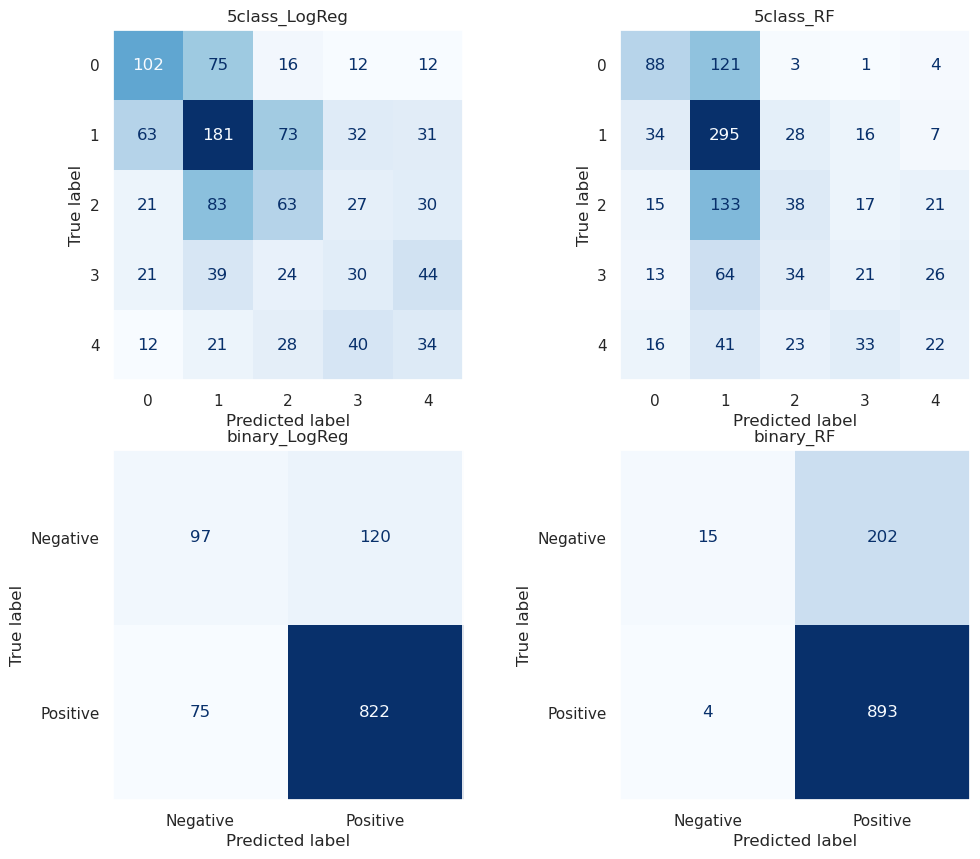

In [15]:
### Run standard evaluation
std_eval_name = os.path.basename(model_dir[:-1])

# Train set
rows, cms = report(X = train_all_means, 
                   y = train_all[5]['severity_score_adjusted'].detach().cpu().numpy(),
                   name = std_eval_name)

# Val set
# rows, cms = report(X = val_all_means,
#                    y = val_all[5]['severity_score_adjusted'].detach().cpu().numpy(),
#                    name = std_eval_name)

# --- save: per-run metrics, confusion matrices, and append to a master table ---
output_dir = model_dir
safe = ''.join(c if c.isalnum() or c in '-_' else '_' for c in std_eval_name)
run_df = pd.DataFrame(rows)
run_df.to_csv(os.path.join(output_dir, f'metrics_{safe}.csv'), index=False)
for k, cm in cms.items():
    np.savetxt(os.path.join(output_dir, f'confusion_{safe}_{k}.csv'), cm, fmt='%d', delimiter=',')
master = os.path.join(output_dir, 'all_methods_comparison.csv')
prev = pd.read_csv(master) if os.path.exists(master) else pd.DataFrame()
if len(prev):   # re-running a name overwrites its old rows
    key = ['method', 'task', 'classifier']
    prev = prev[~prev[key].apply(tuple, 1).isin(run_df[key].apply(tuple, 1))]
pd.concat([prev, run_df], ignore_index=True).to_csv(master, index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

### Save confusion matrix
for ax, (name, cm) in zip(axes, cms.items()):
    # Choose labels based on matrix size
    if cm.shape[0] == 2:
        labels = ["Negative", "Positive"]
    else:
        labels = [str(i) for i in range(cm.shape[0])]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.grid(False)

# fig.suptitle(f"Confusion matrices for run {std_eval_name}")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/cm.png", dpi=300, bbox_inches='tight')

print(f"\n[OK] saved metrics_{safe}.csv (+ confusion matrices) -> {output_dir}/")
print(f"[OK] master comparison table -> {master}")

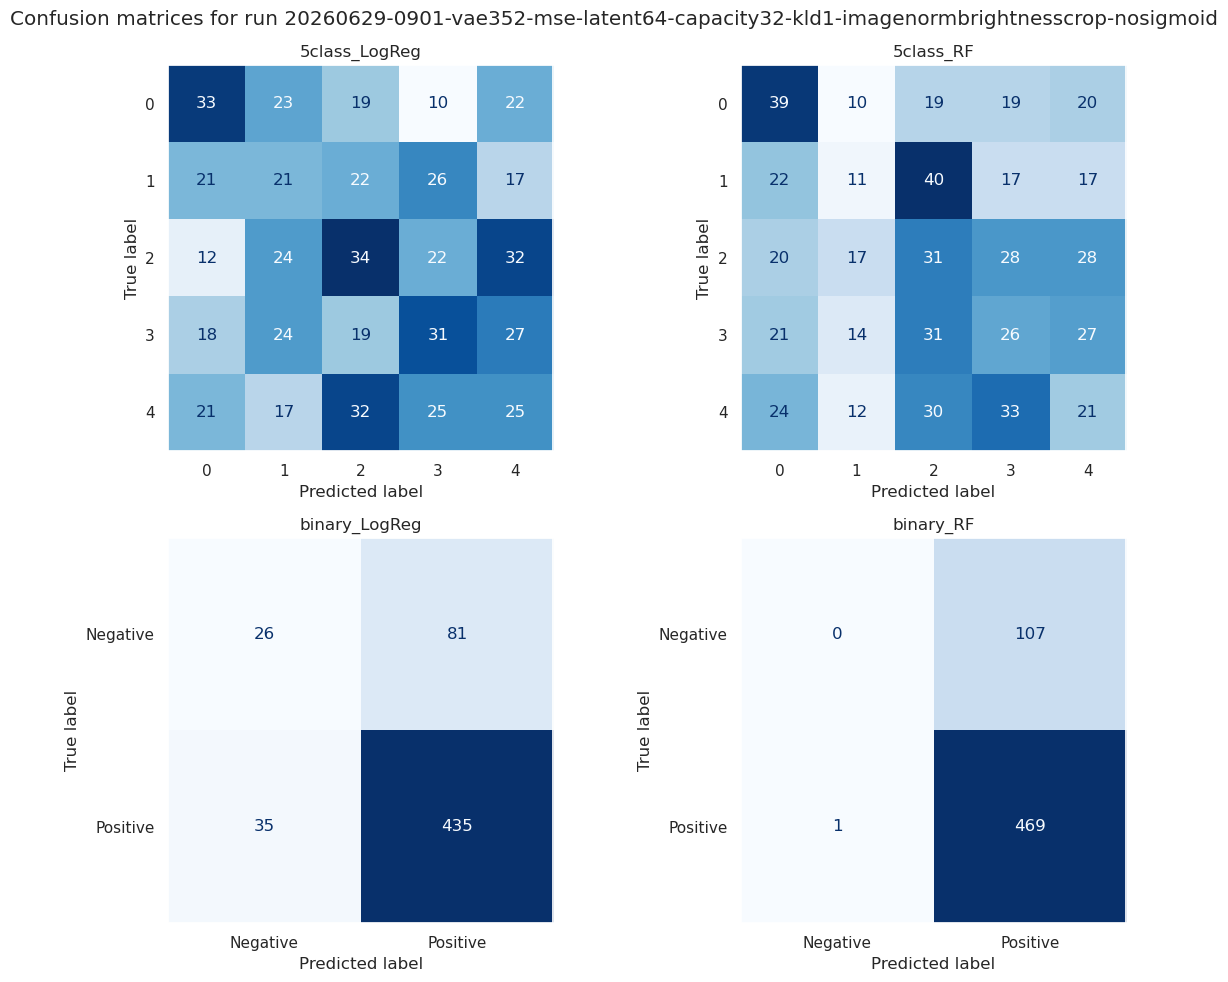

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, cm) in zip(axes, cms.items()):
    # Choose labels based on matrix size
    if cm.shape[0] == 2:
        labels = ["Negative", "Positive"]
    else:
        labels = [str(i) for i in range(cm.shape[0])]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.grid(False)

fig.suptitle(f"Confusion matrices for run {std_eval_name}")
plt.tight_layout()
plt.show()

### Combine csv outputs from standard eval applied across all sweeps

In [5]:
from pathlib import Path
import csv

base_dir = Path("/nfs/research/birney/users/esther/medaka-ziram/results/sweep_mmosfr4n")
output_file = base_dir / "combined_all_methods_comparison_200.csv"

header_written = False

with output_file.open("w", newline="") as outfile:
    writer = csv.writer(outfile)

    # Iterate through each subdirectory
    for d in sorted(p for p in base_dir.iterdir() if p.is_dir()):
        csv_file = d / "all_methods_comparison.csv"

        if not csv_file.exists():
            continue

        with csv_file.open("r", newline="") as infile:
            reader = csv.reader(infile)

            # Read and optionally write the header
            header = next(reader)
            if not header_written:
                writer.writerow(header)
                header_written = True

            # Write all data rows
            writer.writerows(reader)

print(f"Combined CSV written to {output_file}")

Combined CSV written to /nfs/research/birney/users/esther/medaka-ziram/results/sweep_mmosfr4n/combined_all_methods_comparison_200.csv


### Stratified train/test split for F2
Using sklearn train_test_split

In [18]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [19]:
ziram_full_dataset_balanced = pd.read_csv("/nfs/research/birney/users/esther/medaka-ziram/data/Ziram_Full_Dataset_balanced.csv")

In [20]:
ziram_full_dataset_balanced_testonly = ziram_full_dataset_balanced[ziram_full_dataset_balanced["set"] == "test"]

In [24]:
ziram_full_dataset_balanced_testonly["severity_score_adjusted"].value_counts()

severity_score_adjusted
1    1095
0     442
2     401
3     153
4      59
Name: count, dtype: int64

In [25]:
ziram_full_dataset_balanced_testonly

,image_path,set,generation,severity_score,severity_score_adjusted,kinks_number,plate,well,id,line,exposure_type,cross,tank
781,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,2.0,1,4,MG1,A1,MG1A1,NaN,NaN,129-1x14-2,6416.0
782,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,2.0,1,4,MG1,A2,MG1A2,NaN,NaN,129-1x14-2,6417.0
783,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,1.0,1,1,MG1,A3,MG1A3,NaN,NaN,129-1x14-2,6421.0
784,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,1.0,1,1,MG1,A4,MG1A4,NaN,NaN,129-1x14-2,6421.0
785,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,4.0,4,11,MG1,A5,MG1A5,NaN,NaN,129-1x14-2,6423.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3130,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG26,E7,MG26E7,NaN,NaN,79-2x129-1,6460.0
3131,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG26,E8,MG26E8,NaN,NaN,79-2x129-1,6460.0
3132,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,1.0,1,1,MG26,E9,MG26E9,NaN,NaN,79-2x129-1,6460.0
3133,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG26,E10,MG26E10,NaN,NaN,79-2x129-1,6460.0


In [34]:
n_per_severity = {
    0: 50,
    1: 50,
    2: 40,
    3: 40,
    4: 40
}

train_df = pd.concat(
    [
        ziram_full_dataset_balanced_testonly[ziram_full_dataset_balanced_testonly["severity_score_adjusted"] == severity].sample(
            n=n,
            replace=False,
            random_state=42,
        )
        for severity, n in n_per_severity.items()
    ],
)
test_df = ziram_full_dataset_balanced_testonly.drop(train_df.index)

In [35]:
train_df

,image_path,set,generation,severity_score,severity_score_adjusted,kinks_number,plate,well,id,line,exposure_type,cross,tank
2824,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG23,C10,MG23C10,NaN,NaN,58-2x79-2,6443.0
2536,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG20,C10,MG20C10,NaN,NaN,58-2x117-2,6414.0
1009,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG3,D1,MG3D1,NaN,NaN,79-2x129-1,6458.0
2922,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG24,D1,MG24D1,NaN,NaN,14-2x58-2,6450.0
1010,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG3,D2,MG3D2,NaN,NaN,79-2x129-1,6458.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2336,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,4.0,4,12,MG18,B12,MG18B12,NaN,NaN,14-2x58-2,6447.0
1664,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,4.0,4,14,MG10,C9,MG10C9,NaN,NaN,129-1x14-2,6420.0
1658,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,4.0,4,12,MG10,C3,MG10C3,NaN,NaN,129-1x14-2,6417.0
1430,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,4.0,4,11,MG7,H3,MG7H3,NaN,NaN,14-2x117-2,6427.0


In [37]:
test_df

,image_path,set,generation,severity_score,severity_score_adjusted,kinks_number,plate,well,id,line,exposure_type,cross,tank
781,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,2.0,1,4,MG1,A1,MG1A1,NaN,NaN,129-1x14-2,6416.0
782,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,2.0,1,4,MG1,A2,MG1A2,NaN,NaN,129-1x14-2,6417.0
783,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,1.0,1,1,MG1,A3,MG1A3,NaN,NaN,129-1x14-2,6421.0
784,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,1.0,1,1,MG1,A4,MG1A4,NaN,NaN,129-1x14-2,6421.0
786,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,1.0,1,2,MG1,A6,MG1A6,NaN,NaN,129-1x14-2,6423.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3130,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG26,E7,MG26E7,NaN,NaN,79-2x129-1,6460.0
3131,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG26,E8,MG26E8,NaN,NaN,79-2x129-1,6460.0
3132,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,1.0,1,1,MG26,E9,MG26E9,NaN,NaN,79-2x129-1,6460.0
3133,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG26,E10,MG26E10,NaN,NaN,79-2x129-1,6460.0


In [38]:
train_df["severity_score_adjusted"].value_counts()

severity_score_adjusted
0    50
1    50
2    40
3    40
4    40
Name: count, dtype: int64

In [ ]:
stratify_labels = ziram_full_dataset_balanced_testonly["severity_score_adjusted"].astype(str) + "_" + \
                    # ziram_full_dataset_balanced_testonly["cross"].astype(str) # + "_" + \
                    # ziram_full_dataset_balanced_testonly["tank"].astype(str)

In [10]:
train_df, test_df = train_test_split(
    ziram_full_dataset_balanced_testonly,
    test_size=0.75,
    stratify=stratify_labels,
    random_state=42
)

In [39]:
train_df["set"] = "training"

In [40]:
### Combine old train, val with new train_df, test_df
ziram_full_dataset_balanced_trainonly = ziram_full_dataset_balanced[ziram_full_dataset_balanced["set"] == "training"]
ziram_full_dataset_balanced_valonly = ziram_full_dataset_balanced[ziram_full_dataset_balanced["set"] == "validation"]

combined_new = pd.concat([ziram_full_dataset_balanced_trainonly, train_df, ziram_full_dataset_balanced_valonly, test_df], axis=0)

In [41]:
combined_new

,image_path,set,generation,severity_score,severity_score_adjusted,kinks_number,plate,well,id,line,exposure_type,cross,tank
0,/nfs/research/birney/users/esther/medaka-ziram...,training,F0,3.0,3,9,Plate 11,WE00011,Plate 11_11,10-1,Ziram,NaN,NaN
1,/nfs/research/birney/users/esther/medaka-ziram...,training,F0,4.0,4,11,Plate 11,WE00012,Plate 11_12,10-1,Ziram,NaN,NaN
2,/nfs/research/birney/users/esther/medaka-ziram...,training,F0,0.0,0,0,Plate 11,WE00085,Plate 11_85,10-1,DMSO,NaN,NaN
3,/nfs/research/birney/users/esther/medaka-ziram...,training,F0,0.0,0,0,Plate 11,WE00086,Plate 11_86,10-1,DMSO,NaN,NaN
4,/nfs/research/birney/users/esther/medaka-ziram...,training,F0,2.0,1,4,Plate 14,WE00027,Plate 14_27,10-1,Ziram,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3130,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG26,E7,MG26E7,NaN,NaN,79-2x129-1,6460.0
3131,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG26,E8,MG26E8,NaN,NaN,79-2x129-1,6460.0
3132,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,1.0,1,1,MG26,E9,MG26E9,NaN,NaN,79-2x129-1,6460.0
3133,/nfs/research/birney/projects/indigene/raw_dat...,test,F2,0.0,0,0,MG26,E10,MG26E10,NaN,NaN,79-2x129-1,6460.0


In [44]:
combined_new["severity_score_adjusted"].value_counts()

severity_score_adjusted
1    1338
0     661
2     599
3     324
4     213
Name: count, dtype: int64

In [45]:
combined_new.to_csv("/nfs/research/birney/users/esther/medaka-ziram/data/Ziram_Full_Dataset_trainrebalancedF2.csv", index=False)

In [19]:
stratify_labels.value_counts()

1_129-1x14-2    257
1_58-2x79-2     164
1_79-2x14-2     145
1_79-2x129-1    144
1_14-2x117-2    125
1_58-2x117-2    113
2_129-1x14-2    110
0_79-2x129-1    104
1_129-1x58-2     79
0_58-2x79-2      74
1_14-2x58-2      68
2_58-2x79-2      65
0_79-2x14-2      64
2_14-2x117-2     58
0_14-2x117-2     46
0_129-1x14-2     45
0_14-2x58-2      45
2_129-1x58-2     44
0_58-2x117-2     44
3_129-1x14-2     41
2_58-2x117-2     38
2_14-2x58-2      36
2_79-2x129-1     29
3_58-2x117-2     24
3_14-2x117-2     23
2_79-2x14-2      21
0_129-1x58-2     20
3_58-2x79-2      19
3_14-2x58-2      18
3_129-1x58-2     17
4_129-1x14-2     15
4_14-2x117-2     13
4_129-1x58-2     12
4_14-2x58-2       9
3_79-2x129-1      8
4_58-2x117-2      5
4_58-2x79-2       3
3_79-2x14-2       3
4_79-2x129-1      2
Name: count, dtype: int64